# Compare loading times of DEA data using `odc.stac` and `datacube`

In [1]:
import odc.stac
import pystac_client
import datacube
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from odc.geo.geom import BoundingBox

## Connect to STAC API and connect to datacube

In [2]:
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

odc.stac.configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
)

dc = datacube.Datacube()

# Summary product

## Define inputs for analysis

In [3]:
product = "ga_ls8cls9c_gm_cyear_3"
bands = ["nbart_red","nbart_green","nbart_blue"]
years = [2015,2016,2017,2018,2019,2020]

## Define multiple bounding boxes to perform the test on areas of different size

In [4]:
# Starting point in middle of Australia
start_y = -26
start_x = 138

# Buffer size (length of a side of square) to increase study area (in lat/lon degrees)
buffer = 0.5 # approx 50km

y_x_ranges = []
for _ in range(2):
    y_x_ranges.append(
        (
            (start_y + buffer/2, start_y - buffer/2), (start_x - buffer/2, start_x + buffer/2), f"{buffer}x{buffer}_degrees" # lat range, lon range, buffer area in degrees
        )
    )
    buffer*=2  # double the buffer

y_x_ranges

[((-25.75, -26.25), (137.75, 138.25), '0.5x0.5_degrees'),
 ((-25.5, -26.5), (137.5, 138.5), '1.0x1.0_degrees')]

## Initiate dataframe to store the analysis results

In [5]:
# Initiate dataframe
df = pd.DataFrame({'time_steps': list(range(1, len(years)+1))})

# add columns 
for _, _, area in y_x_ranges:
    df[f'odc_stac_{area}_deg'] = None
    df[f'datacube_{area}_deg'] = None

## Run analysis
Count the time needed for loading the same data cube with `odc.stac` vs `datacube`. 
Repeat load for each unique query multiple times and average the loading times, to obtain more robust results.

In [6]:
num_repeats = 5 # repeat every load multiple times to get more robust results

for i, year in enumerate(years):  # iterate years
    print(f"Years: {year-i} to {year}")

    for y_range, x_range, area in y_x_ranges:
        print(f"Area: {area}")

        bbox = BoundingBox.from_xy(x_range, y_range)

        stac_times = []
        dc_times = []

        for _ in range(num_repeats):
            # Load with odc.stac and time
            start = time.time()
            stac_search = catalog.search(
                bbox=bbox,
                collections=[product],
                datetime=f"{year-i}-01-01/{year}-12-31", # first iteration this will be one year, and increase range by one year in next ones, always starting from initial year
            )
            items = list(stac_search.items())
            ds_stac = odc.stac.load(
                items=items,
                bands=bands,
                resolution=30,
                crs="EPSG:3577",
                bbox=bbox,
            )
            _ = ds_stac[bands[0]].mean().data # do some computation
            stac_times.append(time.time() - start)

            # Load with datacube.load and time
            start = time.time()
            ds_dc = dc.load(
                product=product,
                measurements=bands,
                output_crs="EPSG:3577",
                resolution=(-30, 30),
                x=x_range,
                y=y_range,
                time=(f"{year-i}-01-01",f"{year}-12-31"),
            )
            _ = ds_dc[bands[0]].mean().data # do some computation
            dc_times.append(time.time() - start)

        # Save mean times in dataframe
        df.loc[df['time_steps'] == i+1, f'odc_stac_{area}_deg'] = np.mean(stac_times)
        df.loc[df['time_steps'] == i+1, f'datacube_{area}_deg'] = np.mean(dc_times)

Years: 2015 to 2015
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees
Years: 2015 to 2016
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees
Years: 2015 to 2017
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees
Years: 2015 to 2018
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees
Years: 2015 to 2019
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees
Years: 2015 to 2020
Area: 0.5x0.5_degrees
Area: 1.0x1.0_degrees


## Plot results

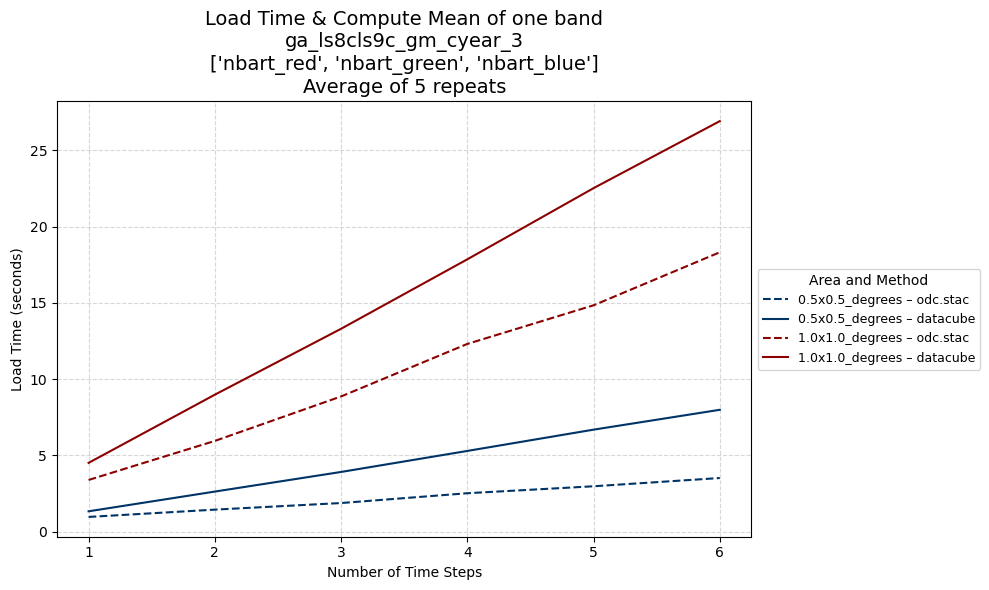

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = {
    'odc_stac': '--',
    'datacube': '-'
}

colours = ['#003366', '#8B0000', '#B8860B']  # dark blue, dark red, dark yellow

for i, (_, _, area) in enumerate(y_x_ranges):
    ax.plot(
        df['time_steps'],
        df[f'odc_stac_{area}_deg'],
        label=f'{area} – odc.stac',
        linestyle=line_styles['odc_stac'],
        color=colours[i]
    )
    ax.plot(
        df['time_steps'],
        df[f'datacube_{area}_deg'],
        label=f'{area} – datacube',
        linestyle=line_styles['datacube'],
        color=colours[i]
    )

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title(f"Load Time & Compute Mean of one band\n{product}\n{bands}\nAverage of {num_repeats} repeats", fontsize=14)
ax.set_xlabel("Number of Time Steps")
ax.set_ylabel("Load Time (seconds)")

# Legend outside the plot, on the right
ax.legend(title="Area and Method", fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# Scenes/ARD product

## Define inputs for analysis

In [8]:
product = "ga_s2am_ard_3"
bands = ["nbart_red","nbart_green","nbart_blue"]
year = "2024" # we will load different time ranges within the same year

## Define bounding box for filtering scenes to load

In [9]:
# Starting point 
y = -35
x = 149

# Buffer size in lat/lon degrees
buffer = 0.05 # approx 5km, which means buffer of side of approx 10km

y_range = (y+buffer, y-buffer)
x_range = (x-buffer, x+buffer)

bbox = BoundingBox.from_xy(x_range, y_range)

## Initiate dataframe to store the analysis results

In [10]:
# Define time ranges: first 4 months, first 8 months, full year
time_ranges = {
    "4_months": f"{year}-01-01/{year}-04-30",
    "8_months": f"{year}-01-01/{year}-08-31",
    "12_months": f"{year}-01-01/{year}-12-31",
}

# Initialize dataframe to store results
df = pd.DataFrame(columns=['time_range', 'odc_stac_time', 'datacube_time'])


## Run analysis
Count the time needed for loading the same data cube with `odc.stac` vs `datacube`. 
Repeat load for each unique query multiple times and average the loading times, to obtain more robust results.

In [11]:
num_repeats = 5

for period_name, time_range in time_ranges.items():
    print(f"Loading data for {period_name} ({time_range})")
 
    stac_times = []
    dc_times = []

    for _ in range(num_repeats):
        # Load with odc.stac.load
        start = time.time()
        stac_search = catalog.search(
            bbox=bbox,
            collections=[product],
            datetime=time_range,
        )
        items = list(stac_search.items())
        ds_stac = odc.stac.load(
            items=items,
            bands=bands,
            resolution=30,
            crs="EPSG:3577",
            bbox=bbox,
        )
        _ = ds_stac[bands[0]].mean().data # do some computation
        stac_times.append(time.time() - start)

        # Load with datacube.load
        start = time.time()
        ds_dc = dc.load(
            product=product,
            measurements=bands,
            output_crs="EPSG:3577",
            resolution=(-30, 30),
            x=x_range,
            y=y_range,
            time=time_range.split('/'),
        )
        _ = ds_dc[bands[0]].mean().data # do some computation
        dc_times.append(time.time() - start)

    new_row = pd.DataFrame([{
        'time_range': period_name,
        'odc_stac_time': np.mean(stac_times),
        'datacube_time': np.mean(dc_times)
    }])
    
    df = pd.concat([df, new_row], ignore_index=True)

Loading data for 4_months (2024-01-01/2024-04-30)


/tmp/ipykernel_829/3627074109.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Loading data for 8_months (2024-01-01/2024-08-31)
Loading data for 12_months (2024-01-01/2024-12-31)


## Plot results

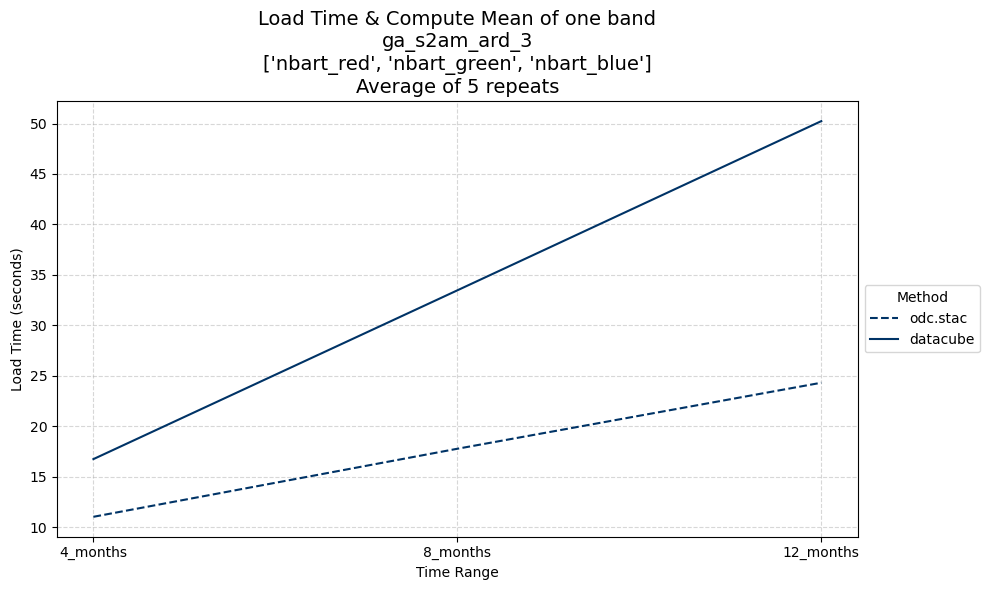

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = {
    'odc_stac': '--',
    'datacube': '-'
}

colours = ['#003366', '#003366']  

# Make sure time_range is sorted as 4, 8, 12 months
order = ['4_months', '8_months', '12_months']
df['time_range'] = pd.Categorical(df['time_range'], categories=order, ordered=True)
df = df.sort_values('time_range')

x = df['time_range']

ax.plot(
    x,
    df['odc_stac_time'],
    label='odc.stac',
    linestyle=line_styles['odc_stac'],
    color=colours[0],
)

ax.plot(
    x,
    df['datacube_time'],
    label='datacube',
    linestyle=line_styles['datacube'],
    color=colours[1],
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title(f"Load Time & Compute Mean of one band\n{product}\n{bands}\nAverage of {num_repeats} repeats", fontsize=14)
ax.set_xlabel("Time Range")
ax.set_ylabel("Load Time (seconds)")

# Legend outside the plot, on the right
ax.legend(title="Method", fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()